Câu 1

In [37]:
# Cấu hình 10 epochs
num_epochs = 10
model = MNIST_CNN().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

    # Đánh giá
    test_loss, test_acc = evaluate(model, test_loader)
    print(f'Epoch {epoch+1}: Test Accuracy = {test_acc:.4f}')

Epoch 1: Test Accuracy = 0.9812
Epoch 2: Test Accuracy = 0.9861
Epoch 3: Test Accuracy = 0.9864
Epoch 4: Test Accuracy = 0.9869
Epoch 5: Test Accuracy = 0.9883
Epoch 6: Test Accuracy = 0.9878
Epoch 7: Test Accuracy = 0.9896
Epoch 8: Test Accuracy = 0.9897
Epoch 9: Test Accuracy = 0.9898
Epoch 10: Test Accuracy = 0.9897


Câu 2

In [38]:
# 1. Định nghĩa model mới (với conv3)
class MNIST_CNN_3Layers(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 3 * 3, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

# 2. KHỞI TẠO VÀ CHẠY THỬ (Đây là bước quan trọng để "ra kết quả")
model_3l = MNIST_CNN_3Layers().to(device)
print(model_3l) # In ra cấu trúc mạng để xác nhận là model đã được tạo

# Test nhanh với 1 batch dữ liệu để xem có lỗi shape không
data, _ = next(iter(train_loader))
output = model_3l(data.to(device))
print(f"\nKích thước output của model: {output.shape}") # Phải ra [64, 10]

MNIST_CNN_3Layers(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=576, out_features=10, bias=True)
)

Kích thước output của model: torch.Size([64, 10])


Câu 3

Đang huấn luyện với lr=0.001...
Đang huấn luyện với lr=0.01...
Đang huấn luyện với lr=0.1...


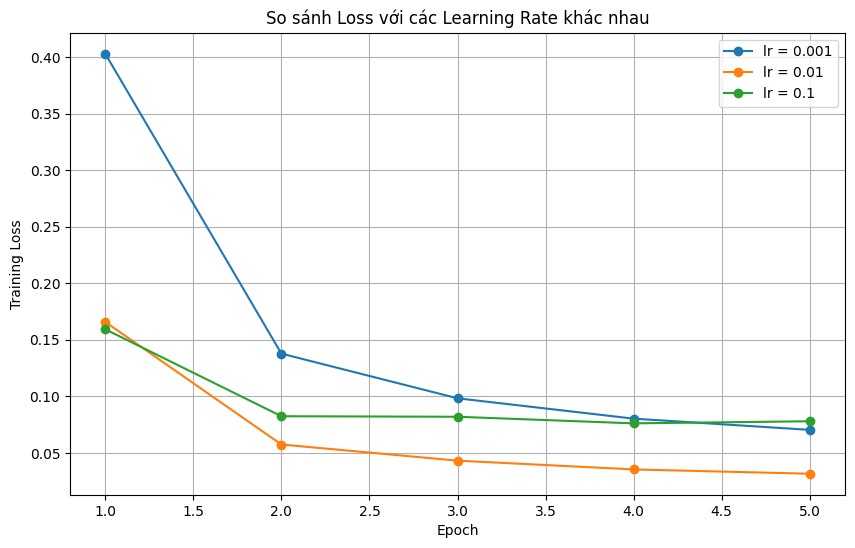

In [39]:
import matplotlib.pyplot as plt

lrs = [0.001, 0.01, 0.1]
plt.figure(figsize=(10, 6)) # Tạo khung bảng

for lr in lrs:
    print(f"Đang huấn luyện với lr={lr}...")
    # Khởi tạo lại model và optimizer cho mỗi lr
    model = MNIST_CNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()

    loss_history = []
    # Train 5 epoch
    for epoch in range(5):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Lưu loss trung bình của epoch
        loss_history.append(running_loss / len(train_loader))

    # Vẽ đường loss sau khi train xong 5 epoch của lr đó
    plt.plot(range(1, 6), loss_history, marker='o', label=f'lr = {lr}')

plt.title('So sánh Loss với các Learning Rate khác nhau')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(True)
plt.show() # LỆNH NÀY RẤT QUAN TRỌNG ĐỂ HIỆN HÌNH

Câu 4

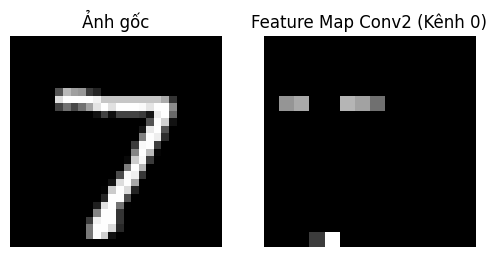

In [40]:
import matplotlib.pyplot as plt

# 1. Chuyển model sang chế độ đánh giá
model.eval()

# 2. Lấy một ảnh từ test_loader
data, _ = next(iter(test_loader))
img = data[0:1].to(device) # Chỉ lấy 1 ảnh đầu tiên, đưa lên GPU

with torch.no_grad():
    # Đi qua các tầng để lấy feature map của conv2
    h1 = model.pool(torch.relu(model.conv1(img)))
    h2 = torch.relu(model.conv2(h1))

# 3. CHUYỂN VỀ CPU VÀ CHUẨN HÓA ĐỂ VẼ (Quan trọng)
# Chuyển về CPU, tách gradient, và lấy kênh đầu tiên (index 0)
fmap_conv2 = h2[0, 0].cpu().numpy()

# 4. Hiển thị
plt.figure(figsize=(6, 3))

# Ảnh gốc
plt.subplot(1, 2, 1)
plt.imshow(img.cpu().squeeze(), cmap='gray')
plt.title('Ảnh gốc')
plt.axis('off')

# Feature Map Conv2
plt.subplot(1, 2, 2)
plt.imshow(fmap_conv2, cmap='gray')
plt.title('Feature Map Conv2 (Kênh 0)')
plt.axis('off')

plt.show()

Câu 5

In [41]:
# Augmentation chỉ áp dụng cho tập train
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Test thì giữ nguyên, không dùng augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Tạo lại loader
train_loader_aug = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=True, download=True, transform=train_transform_aug),
    batch_size=64, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data', train=False, download=True, transform=test_transform),
    batch_size=64, shuffle=False
)

In [42]:
class MNIST_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Dropout: ngẫu nhiên tắt 25% các nơ-ron trong quá trình train
        self.dropout = nn.Dropout(p=0.25)
        self.fc1 = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten
        x = self.dropout(x)       # Áp dụng Dropout trước lớp cuối
        x = self.fc1(x)
        return x

model_final = MNIST_CNN_Dropout().to(device)

In [43]:
optimizer = optim.SGD(model_final.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

print("Bắt đầu huấn luyện với Dropout và Augmentation...")
for epoch in range(10):
    model_final.train() # Quan trọng: Phải là .train() để Dropout hoạt động
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_final(images), labels)
        loss.backward()
        optimizer.step()

    # Kiểm tra độ chính xác sau mỗi epoch
    model_final.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_final(images)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1}/10 | Test Accuracy: {correct/total:.4f}")

Bắt đầu huấn luyện với Dropout và Augmentation...
Epoch 1/10 | Test Accuracy: 0.9843
Epoch 2/10 | Test Accuracy: 0.9845
Epoch 3/10 | Test Accuracy: 0.9857
Epoch 4/10 | Test Accuracy: 0.9884
Epoch 5/10 | Test Accuracy: 0.9884
Epoch 6/10 | Test Accuracy: 0.9884
Epoch 7/10 | Test Accuracy: 0.9897
Epoch 8/10 | Test Accuracy: 0.9888
Epoch 9/10 | Test Accuracy: 0.9897
Epoch 10/10 | Test Accuracy: 0.9911
